# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [41]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 100
step_min = 10 # Progress time by 10 minutes

# Deconvolution timepoints for fine grained replication timing
#deconv_tps = np.arange(0, length_timecourse, 10)

# Experimental timepoints for the observed data later on
tps = np.arange(0, length_timecourse, step_min)

# One origin that fires at 25 bp at 10 min
n = 2 # 2 genomic positions
origins = { 3: [1] }

# Replication profile 
toy_repl_example = ToyReplication(n=n, timepoints=tps, origins=origins)
toy_repl_example.replicate()
toy_repl_example.replication_matrix = np.array(
      [[1, 1],
       [1, 1],
       [1, 1],
       [1, 2],
       [1, 2],
       [1, 2],
       [2, 2],
       [2, 2],
       [2, 2],
       [2, 2]])

Text(0.5, 1.0, 'Normalized, corrected')

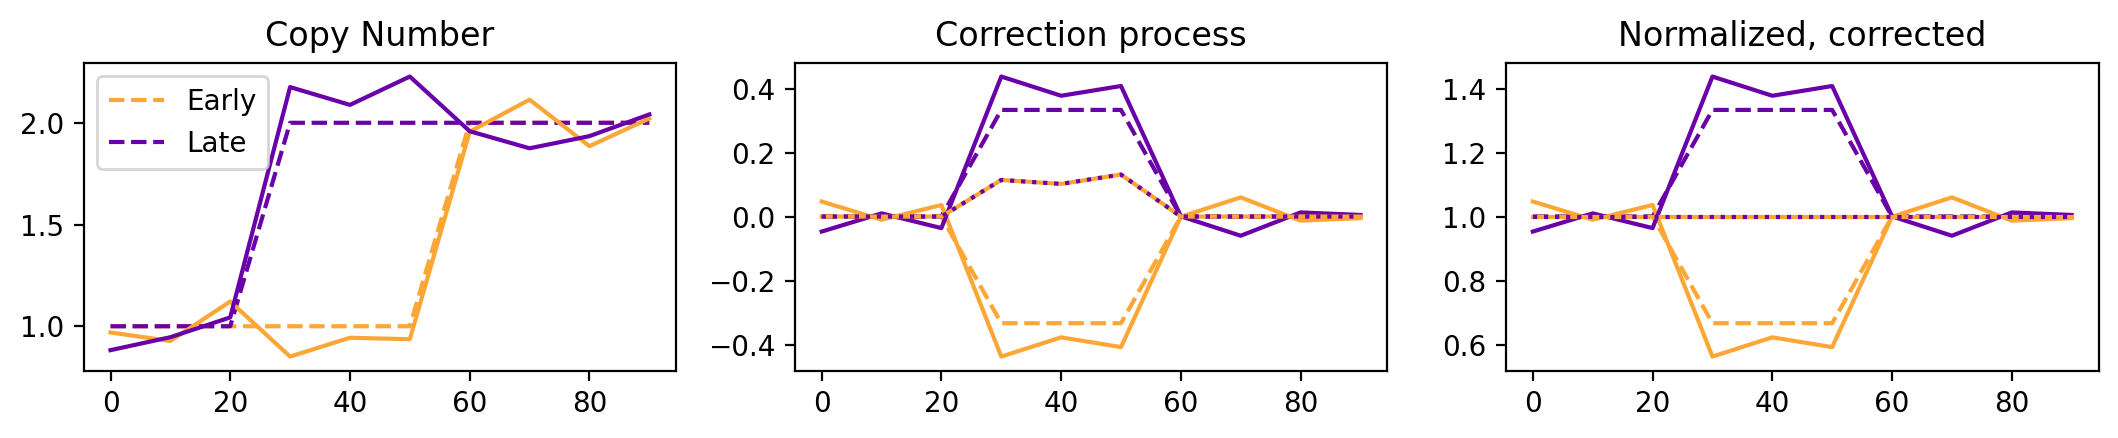

In [128]:
from src.ToyCopyNumberCorrect import plot_reads_bar
from scipy.stats.distributions import norm

replication_matrix = toy_repl_example.replication_matrix

color_early = plt.get_cmap('plasma_r')(0.2)
color_late = plt.get_cmap('plasma_r')(0.8)

plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
plt.plot(tps, replication_matrix[:, 0],  color=color_early, ls='dashed', label="Early")
plt.plot(tps, replication_matrix[:, 1],  color=color_late, ls='dashed', label="Late")
plt.title("Copy Number")
plt.legend()


reads = replication_matrix + norm.rvs(loc=0, scale=0.1, size=replication_matrix.shape)

plt.plot(tps, reads[:, 0], label='Early', color=color_early)
plt.plot(tps, reads[:, 1], label='Late', color=color_late)

plt.subplot(1, 3, 2)
plt.title("Correction process")

normalized_repl = normalize(replication_matrix)
normalized_reads = normalize(reads)
sub1_repl = normalized_repl-1
sub1_reads = normalized_reads-1

plt.plot(tps, sub1_repl[:, 0], label='Early', color=color_early, ls='dashed')
plt.plot(tps, sub1_repl[:, 1], label='Late', color=color_late, ls='dashed')

plt.plot(tps, sub1_reads[:, 0], label='Early', color=color_early, ls='solid')
plt.plot(tps, sub1_reads[:, 1], label='Late', color=color_late, ls='solid')

plt.plot(tps, correction[:, 0]-1, label='Early', color=color_early, ls='solid')
plt.plot(tps, correction[:, 1]-1, label='Late', color=color_late, ls='dotted')

plt.subplot(1, 3, 3)

def normalize(replication_matrix):
    normalized_repl = replication_matrix / replication_matrix.sum(axis=1).reshape((-1, 1)) \
        * replication_matrix.shape[1]
    return normalized_repl



plt.plot(tps, normalized_repl[:, 0], label='Early', color=color_early, ls='dashed')
plt.plot(tps, normalized_repl[:, 1], label='Late', color=color_late, ls='dashed')

plt.plot(tps, normalized_reads[:, 0], label='Early', color=color_early)
plt.plot(tps, normalized_reads[:, 1], label='Late', color=color_late)

correction = (normalized_repl-1) * (normalized_reads-1) + 1
normalized_correction = normalize(correction)

plt.plot(tps, normalized_correction[:, 0], label='Early', color=color_early, ls='solid')
plt.plot(tps, normalized_correction[:, 1], label='Late', color=color_late, ls='dotted')

plt.title("Normalized, corrected")